# Disk Modeling Basics

## Introduction

This notebook provides an introduction to the **disk modeling workflow** in `grater-jax`.  
It shows how the framework builds scattered-light disk images from modular components that represent different physical and instrumental effects.

The model is structured into the following pieces:

- **Dust Distribution** – specifies the 3D density of dust grains (e.g., radial power-law slopes, eccentricity, vertical scale height).  
- **Scattering Phase Function (SPF)** – controls how starlight is scattered by dust as a function of angle (Henyey–Greenstein, double HG, or spline-based models).  
- **Point Spread Function (PSF)** – applies instrument response by convolving the model image with a chosen PSF kernel (Gaussian, empirical, or JWST-style Winnie PSF).  
- **Stellar PSF** – models the central star’s light separately; this will be introduced in a later section.

The notebook demonstrates how to configure these components, run them through the `objective_model` pipeline, and generate synthetic disk images that can be compared directly with observations.


### Setup

In [1]:
import os
os.environ["STPSF_PATH"] = 'stpsf-data'
os.environ["STPSF_EXT_PATH"] = 'stpsf-data'
os.environ["PYSYN_CDBS"] = "cdbs"

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

## Generating Disk Models with Simple PSFs

### Empirical PSF Image

In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("PSFs/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

### Simple Disk Model

In [3]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
spf_params = DoubleHenyeyGreenstein_SPF.params
psf_params = EMP_PSF.params

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30

simple_disk_img = objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

#### Disk Model Image

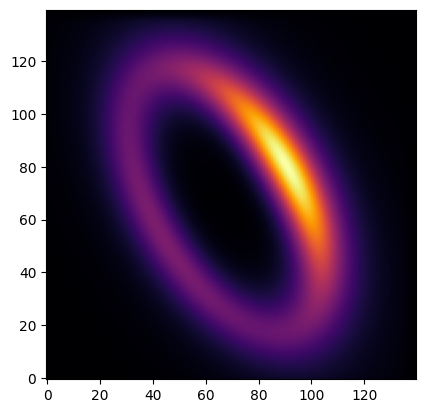

In [4]:
plt.imshow(simple_disk_img, origin='lower', cmap='inferno')

#### Runtime Analysis

In [5]:
%timeit objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

2.24 ms ± 2.91 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Generating Disks with Complex PSFs

### NIRCAM PSF Model

In [6]:
# Need to have im_mask_rolls, psf_inds_rolls, psf_offsets, psfs, and parangs to initialize JWST NIRCam PSF

##################### F360M #################
psf_dir = "PSFs/F360M/"
psf_suffixes = "_F360M.npy"

#Read in the pre-generated PSFs
im_mask_rolls = jnp.load(psf_dir+"im_mask_rolls"+psf_suffixes)
psf_inds_rolls = jnp.load(psf_dir+"psf_inds_rolls"+psf_suffixes)
psf_offsets = jnp.load(psf_dir+"psf_offsets"+psf_suffixes)
psfs = jnp.load(psf_dir+"psfs"+psf_suffixes)

unique_inds = jnp.unique(psf_inds_rolls)
n_unique_inds = len(unique_inds)

test_parangs = jnp.unique(np.linspace(-45, 45, 8))

### Complex Disk Model

In [7]:
# Initializing Parameter Dictionaries
spf_params = InterpolatedUnivariateSpline_SPF.params
psf_params = Winnie_PSF.init(psfs, psf_inds_rolls, im_mask_rolls, psf_offsets, test_parangs, 46)

spf_params['knot_values'] = jnp.array([0.3, 0.5, 0.1, 0.6, 0.9, 0.3])

disk_params = Parameter_Index.disk_params
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30

nircam_disk_img = objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, Winnie_PSF)

#### Disk Model

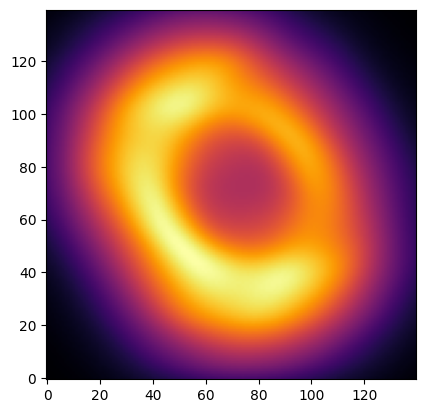

In [8]:
plt.imshow(nircam_disk_img, origin='lower', cmap='inferno')

#### Runtime Analysis

In [9]:
%timeit objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, Winnie_PSF)

69.5 ms ± 13.8 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Forward Modeling

#### Generating a Target Disk

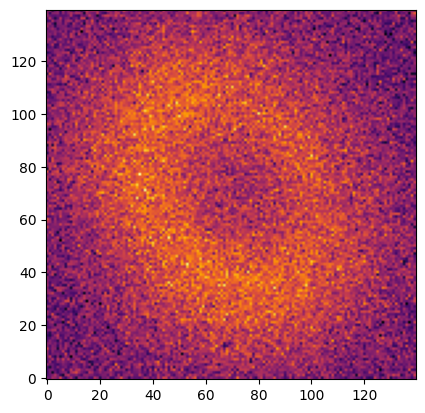

In [10]:
noise_level = 250
noise = np.random.normal(0, noise_level, nircam_disk_img.shape)
target_image = nircam_disk_img + noise
err_map = jnp.ones(nircam_disk_img.shape)*noise_level
plt.imshow(target_image, origin='lower', cmap='inferno')

### Getting the Log-Likelihood

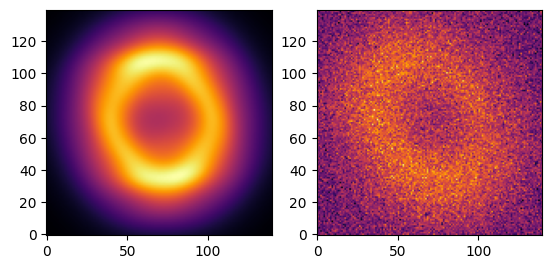

Log-Likelihood: -157068.59436623997


In [11]:
start_spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
start_psf_params = Winnie_PSF.init(psfs, psf_inds_rolls, im_mask_rolls, psf_offsets, test_parangs, 46)

start_disk_params = Parameter_Index.disk_params.copy()
start_disk_params['sma'] = 30
start_disk_params['inclination'] = 45
start_disk_params['position_angle'] = 10
start_spf_params['knot_values'] = jnp.ones(6)

start_image = objective_model(start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params, ScatteredLightDisk,
                              DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, Winnie_PSF)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(start_image, origin='lower', cmap='inferno')
axes[1].imshow(target_image, origin='lower', cmap='inferno')
plt.show()

print(f'Log-Likelihood: {log_likelihood(start_image, target_image, err_map)}')

### Disk Fitting using Scipy Optimize Minimize

In [12]:
from scipy.optimize import minimize

# Specifying parameters to be fit
fit_keys = ['sma', 'inclination', 'position_angle', 'knot_values']

# Creating objective function
llp = lambda x: -objective_fit([x[0], x[1], x[2], x[3:]], fit_keys, disk_params, spf_params, psf_params, Parameter_Index.misc_params,
                              ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, Winnie_PSF, target_image,
                              err_map)

# Initial Parameters (need to be in array form)
init_x = jnp.concatenate([jnp.array([start_disk_params['sma'], start_disk_params['inclination'], start_disk_params['position_angle']]), 0.5*jnp.ones(6)])

soln = minimize(llp, init_x, options={'disp': True, 'max_itr': 500})

/tmp/ipykernel_2245422/1055153753.py:14: OptimizeWarning: Unknown solver options: max_itr
  soln = minimize(llp, init_x, options={'disp': True, 'max_itr': 500})


         Current function value: 118463.384780
         Iterations: 78
         Function evaluations: 2050
         Gradient evaluations: 204


/home/mihirkondapalli/anaconda3/envs/package-env/lib/python3.13/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


#### Numeric Results

In [13]:
print(f"Disk Fit Parameters: {soln.x}")
print(f"Disk Fit Log Likelihood: {-soln.fun}")

Disk Fit Parameters: [41.35776946 60.88878728 10.7363858   1.24443416  0.4696145   0.54277495
 -0.15386034  1.10021324 -0.9419699 ]
Disk Fit Log Likelihood: -118463.38478045657


#### Visual Results

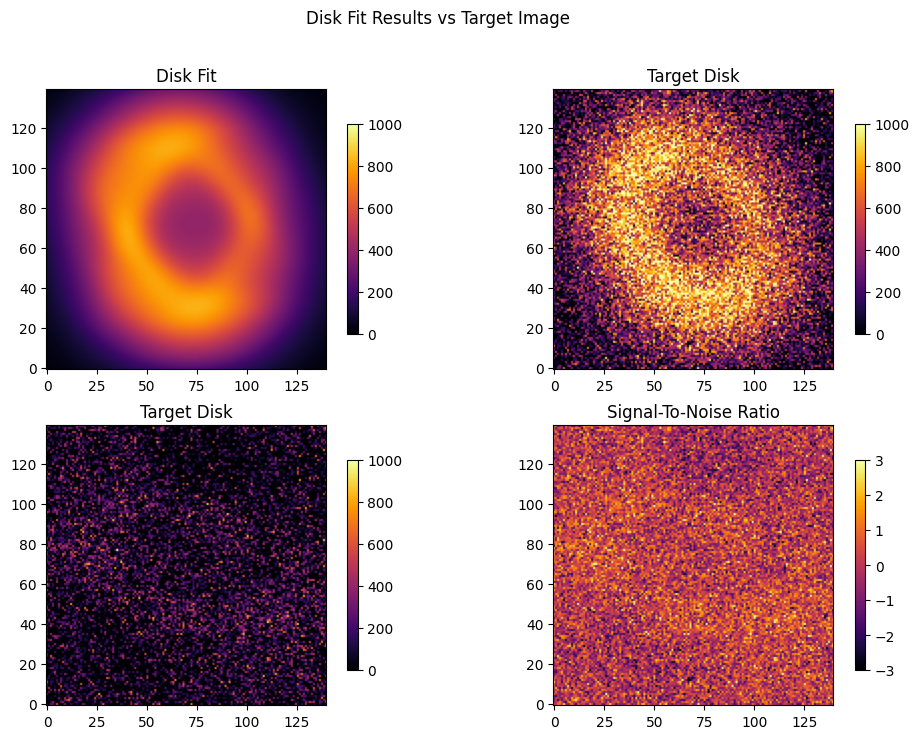

In [14]:
new_disk_params = disk_params.copy()
new_spf_params = spf_params.copy()
new_disk_params['sma'] = soln.x[0]
new_disk_params['inclination'] = soln.x[1]
new_disk_params['position_angle'] = soln.x[2]

fitted_image = objective_model(new_disk_params, new_spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
                                InterpolatedUnivariateSpline_SPF, Winnie_PSF)

fig, axes = plt.subplots(2, 2, figsize=(12,8))
vmin, vmax = 0, 1000

fitted_pic = axes[0][0].imshow(fitted_image, origin='lower', cmap='inferno')
axes[0][0].set_title('Disk Fit')
plt.colorbar(fitted_pic, ax=axes[0][0], shrink=0.75)
fitted_pic.set_clim(vmin, vmax)

target_pic = axes[0][1].imshow(target_image, origin='lower', cmap='inferno')
axes[0][1].set_title('Target Disk')
plt.colorbar(target_pic, ax=axes[0][1], shrink=0.75)
target_pic.set_clim(vmin, vmax)

residual_pic = axes[1][0].imshow(target_image-fitted_image, origin='lower', cmap='inferno')
axes[1][0].set_title('Target Disk')
plt.colorbar(residual_pic, ax=axes[1][0], shrink=0.75)
residual_pic.set_clim(vmin, vmax)

residual_pic = axes[1][1].imshow(np.where(err_map == 0, 0., (target_image-fitted_image)/err_map), origin='lower', cmap='inferno')
axes[1][1].set_title('Signal-To-Noise Ratio')
plt.colorbar(residual_pic, ax=axes[1][1], shrink=0.75)
residual_pic.set_clim(-3, 3)

fig.suptitle("Disk Fit Results vs Target Image")
plt.show()

## Takeaways

As you can see, the process for fitting a disk with just the objective function is very cumbersome and not as precise. If you want a simpler way to work with more complex disks, leverage autodifferentiation, and run comprehensive sampling algorithms, refer to the Advanced Disk Modeling tutorial where we demonstrate the Optimizer class.